In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, callbacks
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv")
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [3]:
features = ['so2', 'co', 'o3', 'pm10', 'pm2.5', 'no2', 'nox', 'no']
X = df[features]
y = df['status']

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [5]:
print(f"Original class distribution: {Counter(y_train)}")

Original class distribution: Counter({np.int64(0): 91885, np.int64(1): 8735, np.int64(2): 111})


In [6]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [7]:
print(f"Resampled class distribution: {Counter(y_train_res)}")

Resampled class distribution: Counter({np.int64(1): 91885, np.int64(0): 91885, np.int64(2): 91885})


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [9]:

input_tensor = layers.Input(shape=(X_train_res.shape[1],))

mod = layers.Dense(256, activation='relu')(input_tensor)
mod = layers.Dropout(0.5)(mod)
mod = layers.Dense(128, activation='relu')(mod) 
mod = layers.Dropout(0.4)(mod)
mod = layers.Dense(64, activation='relu')(mod)
mod = layers.Dropout(0.3)(mod)


feature_output = layers.Dense(32, activation='relu')(mod)
mod = layers.Dropout(0.2)(feature_output)

# Final classification layer
output_tensor = layers.Dense(len(le.classes_), activation='softmax')(mod)

model = models.Model(inputs=input_tensor, outputs=output_tensor)



In [10]:
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_svm.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [11]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train_res, epochs=100, batch_size=128,validation_split=0.2,callbacks=my_callbacks,shuffle=True)

Epoch 1/100
1723/1723 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7817 - loss: 0.4987 - val_accuracy: 0.8585 - val_loss: 0.4693 - learning_rate: 5.0000e-04
Epoch 2/100
1723/1723 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8303 - loss: 0.4104 - val_accuracy: 0.8868 - val_loss: 0.3812 - learning_rate: 5.0000e-04
Epoch 3/100
1723/1723 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8476 - loss: 0.3773 - val_accuracy: 0.9426 - val_loss: 0.2553 - learning_rate: 5.0000e-04
Epoch 4/100
1723/1723 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8570 - loss: 0.3554 - val_accuracy: 0.9648 - val_loss: 0.1893 - learning_rate: 5.0000e-04
Epoch 5/100
1723/1723 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8626 - loss: 0.3427 - val_accuracy: 0.9742 - val_loss: 0.1624 - learning_rate: 5.0000e-04
Epoch 6/100
1723/1723 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8672 - loss: 0.3325 - val_accuracy: 0.9889 - val_loss: 0.1164 - learning_rate: 5.0000e-04
Epoch 7/100
1723/1723 ━━━━━━━━━━━━━━━━━━━━ 7s 

In [ ]:
# Extract features from the trained neural network 
feature_extractor = models.Model(inputs=model.input, outputs=model.layers[-3].output)
X_train_features = feature_extractor.predict(X_train_scaled)
X_test_features = feature_extractor.predict(X_test_scaled)


f_scaler=StandardScaler()
X_features_train_scaled=f_scaler.fit_transform(X_train_features)
X_features_test_scaled=f_scaler.transform(X_test_features)

# Train SVM on the extracted features
svm_model = LinearSVC(dual=False,class_weight='balanced',max_iter=1000,random_state=42)
svm_model.fit(X_features_train_scaled, y_train_res)

# Evaluate SVM
y_pred_svm = svm_model.predict(X_features_test_scaled)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

8615/8615 ━━━━━━━━━━━━━━━━━━━━ 8s 887us/step
787/787 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step
                                precision    recall  f1-score   support

                          Good       0.99      0.87      0.92     22982
                      Moderate       0.38      0.87      0.53      2173
Unhealthy for Sensitive Groups       0.10      0.25      0.14        28

                      accuracy                           0.87     25183
                     macro avg       0.49      0.66      0.53     25183
                  weighted avg       0.93      0.87      0.89     25183



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score,recall_score
from tensorflow.keras.callbacks import EarlyStopping

# Compute global metrics for the SVM model
global_accuracy = accuracy_score(y_test, y_pred_svm)
global_precision = precision_score(y_test, y_pred_svm, average='weighted')
global_f1 = f1_score(y_test, y_pred_svm, average='weighted')
global_recall = recall_score(y_test, y_pred_svm, average='weighted')

print(f"Global Accuracy: {global_accuracy}")
print(f"Global Precision: {global_precision}")
print(f"Global F1-Score: {global_f1}")
print(f"Global Recall: {global_recall}")



Global Accuracy: 0.8651074137314855
Global Precision: 0.9341747117983655
Global F1-Score: 0.8876651859917235
Global Recall: 0.8651074137314855


In [15]:
import joblib

# Save the SVM model to a file
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(f_scaler,"f_scaler.pkl")

['f_scaler.pkl']

In [16]:
joblib.dump(scaler,'scaler.pkl')
joblib.dump(feature_extractor,'feature_extractor.pkl')

['feature_extractor.pkl']

In [17]:
print(list(enumerate(le.classes_)))

[(0, 'Good'), (1, 'Moderate'), (2, 'Unhealthy for Sensitive Groups')]


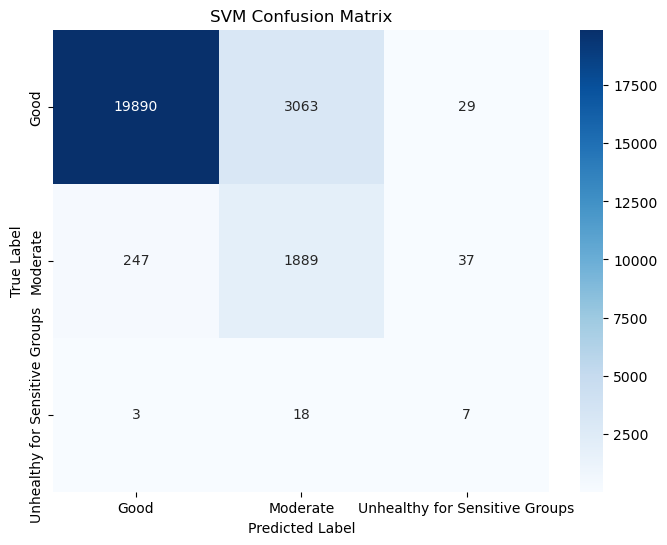

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.show()